**📌 Project Domain**

Prediksi time series harga emas menggunakan deep learning untuk mendukung keputusan investasi dan analisis tren pasar komoditas.

**❗ Problem Statements**

Proyek ini bertujuan untuk mengembangkan model prediksi harga emas menggunakan teknik machine learning untuk membantu investor dalam mengambil keputusan yang lebih baik berdasarkan analisis data historis

**🎯 Goals**

Tujuan proyek ini adalah untuk mengembangkan model prediksi harga emas yang akurat dan mudah digunakan, serta menyediakan visualisasi data dan analisis tren untuk mendukung keputusan investasi yang lebih baik.


**💡 Solution Statements**

Solusi untuk proyek ini adalah mengimplementasikan model machine learning berbasis deep learning yang memanfaatkan data historis harga emas untuk menghasilkan prediksi harga yang akurat, disertai dengan visualisasi interaktif dan analisis tren yang mendukung pengambilan keputusan investasi yang lebih baik



**🧾 Data Understanding**

#iMPORT DATA DARI KAGGLE

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"cctvwilayah4","key":"e0b60ee4abcbb6fd6d57bc5b73d06557"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d altruistdelhite04/gold-price-data


Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/gold-price-data
License(s): unknown


In [4]:
!mkdir crop-recommendation-dataset
!unzip gold-price-data.zip -d crop-recommendation-dataset
!ls crop-recommendation-dataset

Archive:  gold-price-data.zip
  inflating: crop-recommendation-dataset/gld_price_data.csv  
gld_price_data.csv


## Import Library yang dibutuhkan

In [5]:
# Library untuk manipulasi tanggal dan waktu
import datetime

# Library untuk manipulasi data
import numpy as np
import pandas as pd

# Library untuk Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

# Library untuk visualisasi
import matplotlib.pyplot as plt
import matplotlib.dates as mdate
import seaborn as sns

# Library untuk preprocessing dan evaluasi model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from datetime import datetime, timedelta




## Exploratory Data Analysis

In [25]:
data= pd.read_csv('/content/crop-recommendation-dataset/gld_price_data.csv')


In [7]:
data.head()



,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [8]:
data.tail()


,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [9]:

data.shape


(2290, 6)

In [10]:


data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [11]:


data.describe()



,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [12]:


data.duplicated().sum()



np.int64(0)

In [13]:
data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [17]:
data['Date'] = pd.to_datetime(data['Date'])

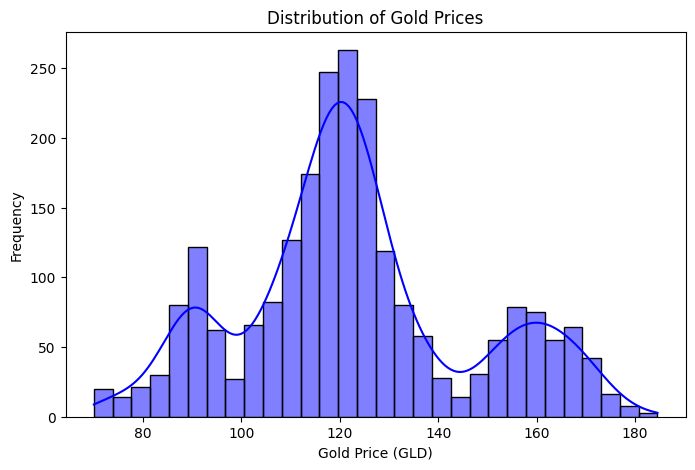

In [18]:

plt.figure(figsize=(8, 5))
sns.histplot(data['GLD'], bins=30, kde=True, color='blue')
plt.xlabel('Gold Price (GLD)')
plt.ylabel('Frequency')
plt.title('Distribution of Gold Prices')
plt.show()



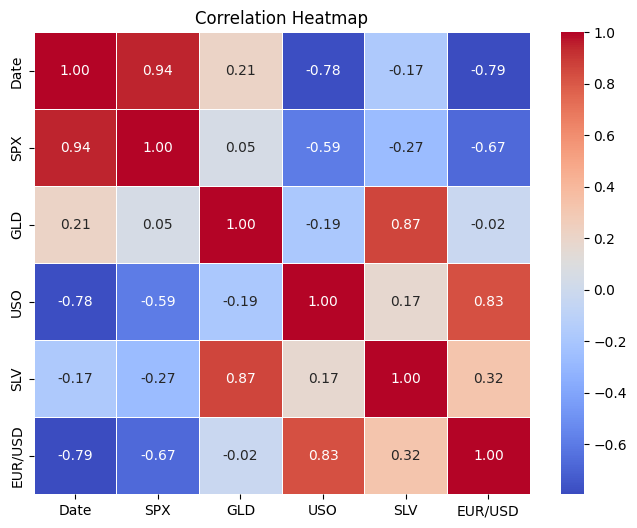

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

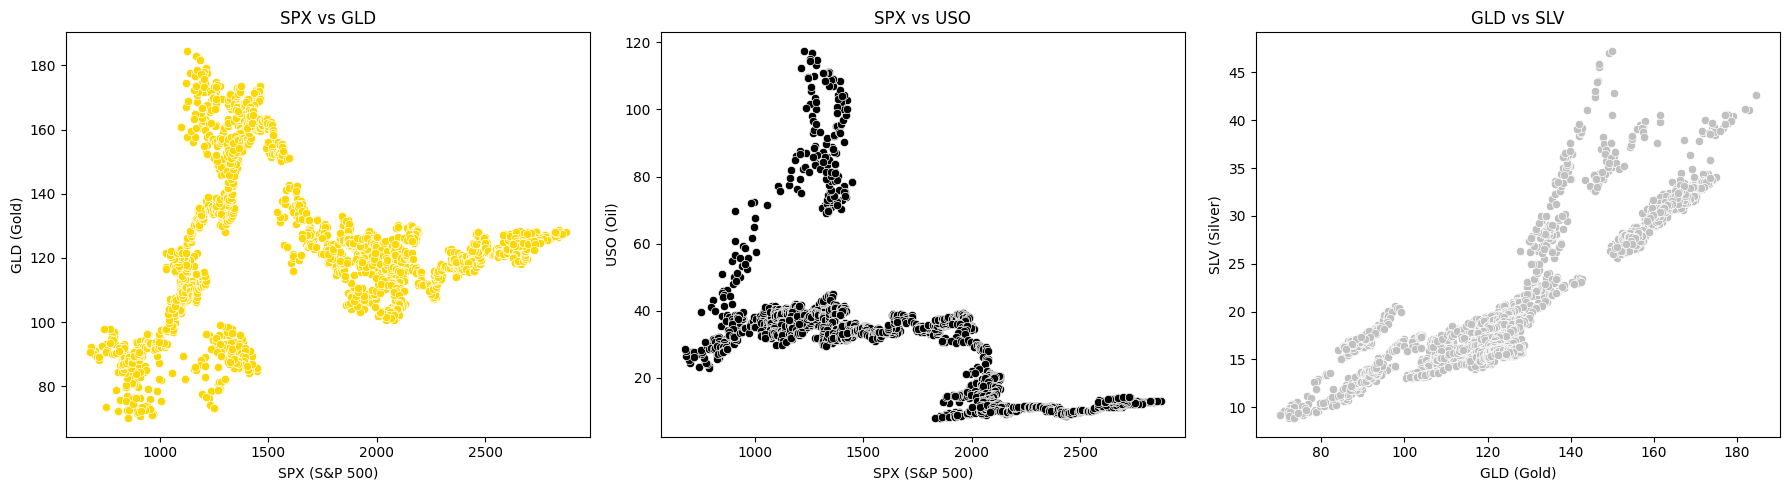

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SPX vs GLD
sns.scatterplot(x=data['SPX'], y=data['GLD'], ax=axes[0], color='gold')
axes[0].set_title('SPX vs GLD')
axes[0].set_xlabel('SPX (S&P 500)')
axes[0].set_ylabel('GLD (Gold)')

# SPX vs USO
sns.scatterplot(x=data['SPX'], y=data['USO'], ax=axes[1], color='black')
axes[1].set_title('SPX vs USO')
axes[1].set_xlabel('SPX (S&P 500)')
axes[1].set_ylabel('USO (Oil)')

# GLD vs SLV
sns.scatterplot(x=data['GLD'], y=data['SLV'], ax=axes[2], color='silver')
axes[2].set_title('GLD vs SLV')
axes[2].set_xlabel('GLD (Gold)')
axes[2].set_ylabel('SLV (Silver)')

plt.tight_layout()
plt.show()



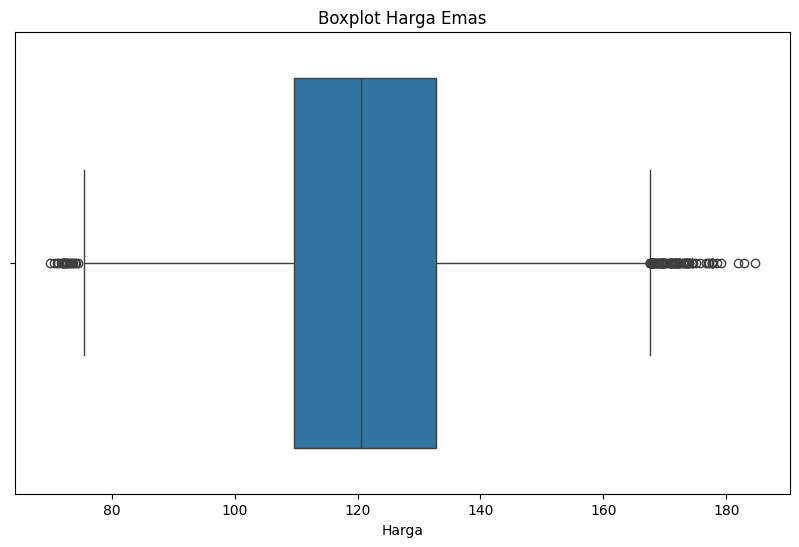

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['GLD'])
plt.title('Boxplot Harga Emas')
plt.xlabel('Harga')
plt.show()


In [26]:
data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


**Data Preparation**

In [35]:
# Tampilkan informasi data
print("Data Info:")
display(data.info())
print("\nData Head:")
display(data.head())
print("\nData Description:")
display(data.describe())

def prepare_data(data, look_back = 60):
    # Normalisasi data
    scaler = MinMaxScaler(feature_range=(0, 1))
    # Change 'Close' to 'GLD' as this is the correct column name
    scaled_data = scaler.fit_transform(data['GLD'].values.reshape(-1, 1))

    # Membuat sequences
    X, y = [], []
    for i in range(look_back, len(scaled_data)):
        X.append(scaled_data[i-look_back:i, 0])
        y.append(scaled_data[i, 0])
    X, y = np.array(X), np.array(y)

    # Reshape untuk LSTM [samples, time steps, features]
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Split data
    train_size = int(len(X) * 0.8)
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_test = X[train_size:]
    y_test = y[train_size:]

    return X_train, X_test, y_train, y_test, scaler

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


None


Data Head:


,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099



Data Description:


,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


**MODELLING**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0535 - mean_absolute_error: 0.1656 - val_loss: 9.9321e-04 - val_mean_absolute_error: 0.0246
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0053 - mean_absolute_error: 0.0538 - val_loss: 9.9395e-04 - val_mean_absolute_error: 0.0249
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0045 - mean_absolute_error: 0.0501 - val_loss: 0.0015 - val_mean_absolute_error: 0.0315
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0048 - mean_absolute_error: 0.0525 - val_loss: 8.5574e-04 - val_mean_absolute_error: 0.0228
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0037 - mean_absolute_error: 0.0463 - val_loss: 9.5398e-04 - val_mean_absolute_error: 0.0247
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.0036 - mean_absolute_error: 0.0456 - val_loss: 0.0012 - val_mean_absolute_error: 0.0274
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0040 - mean_abso

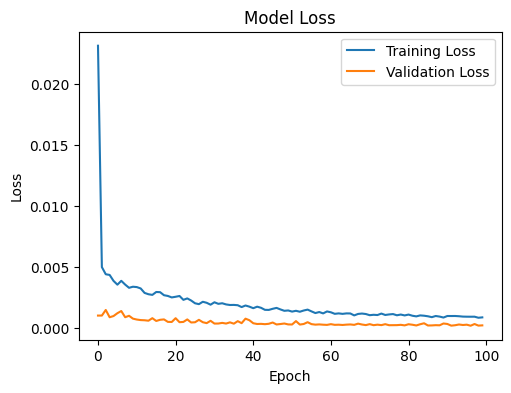

In [39]:
# 1. Tetapkan nilai look_back
look_back = 60

# 2. Persiapan Data
X_train, X_test, y_train, y_test, scaler = prepare_data(data, look_back)
# 3. Definisikan Model LSTM
def create_lstm_model(look_back):
    model = Sequential([
        # Layer 1
        LSTM(units=50,
             return_sequences=True,
             input_shape=(look_back, 1)),
        Dropout(0.2),

        # Layer 2
        LSTM(units=50,
             return_sequences=True),
        Dropout(0.2),

        # Layer 3
        LSTM(units=50),
        Dropout(0.2),

        # Output layer
        Dense(units=1)
    ])

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )

    return model

# Create dan train model
model = create_lstm_model(look_back)
model.summary()

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Training
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Evaluation**

In [45]:
metrics = {

    'Train R²': r2_score(y_train_inv.T, train_predict),
    'Test R²': r2_score(y_test_inv.T, test_predict)
}

# Display metrics with improved formatting
print("\nModel Evaluation Metrics:")
for metric, value in metrics.items():
    if 'RMSE' in metric or 'MAE' in metric:
        print(f"{metric}: Rp {value:,.2f}")
    elif 'R²' in metric:
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")



Model Evaluation Metrics:
Train R²: 0.9930
Test R²: 0.9230


**MODEL SIMULATION**

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Train RMSE (IDR): Rp 35,408.36
Test RMSE (IDR): Rp 22,485.70
Train MAE (IDR): Rp 25,559.69
Test MAE (IDR): Rp 17,682.21
Train R²: 0.9930
Test R²: 0.9230


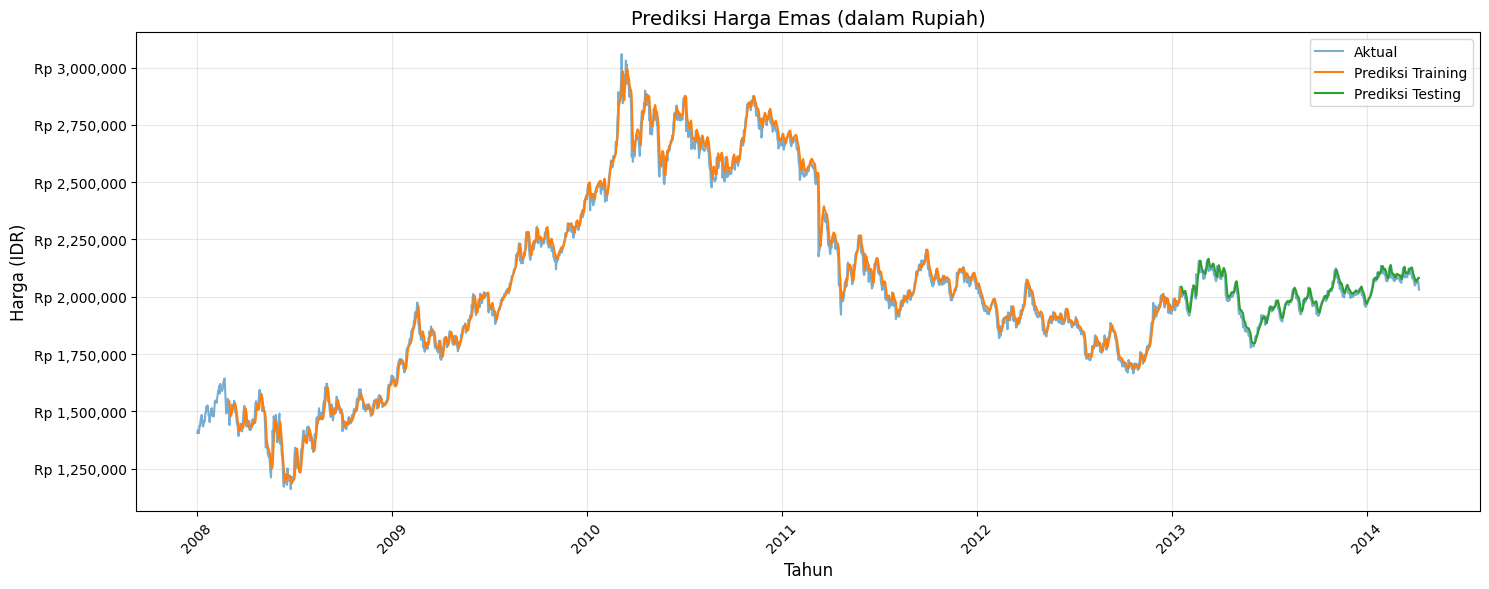


Statistik Harga Emas (dalam Rupiah):
Harga Tertinggi: Rp 3,059,394.59
Harga Terendah: Rp 1,160,180.00
Harga Rata-rata: Rp 2,034,174.67


In [40]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform([y_test])

# Konversi ke Rupiah (asumsikan data awal dalam USD)
exchange_rate = 16574  # Sesuaikan dengan kurs USD to IDR terkini
train_predict_idr = train_predict * exchange_rate
test_predict_idr = test_predict * exchange_rate
actual_prices_idr = df['GLD'].values * exchange_rate

# Calculate metrics
metrics = {
    'Train RMSE (IDR)': np.sqrt(mean_squared_error(y_train_inv.T * exchange_rate, train_predict_idr)),
    'Test RMSE (IDR)': np.sqrt(mean_squared_error(y_test_inv.T * exchange_rate, test_predict_idr)),
    'Train MAE (IDR)': mean_absolute_error(y_train_inv.T * exchange_rate, train_predict_idr),
    'Test MAE (IDR)': mean_absolute_error(y_test_inv.T * exchange_rate, test_predict_idr),
    'Train R²': r2_score(y_train_inv.T, train_predict),
    'Test R²': r2_score(y_test_inv.T, test_predict)
}

# Display metrics
for metric, value in metrics.items():
    if 'IDR' in metric:
        print(f"{metric}: Rp {value:,.2f}")
    else:
        print(f"{metric}: {value:.4f}")

# Plot predictions dengan format Rupiah dan tahun
plt.figure(figsize=(15, 6))

# Konversi index ke tahun
years = pd.date_range(start=df['Date'].iloc[0], periods=len(df), freq='D')

# Plot data aktual dan prediksi
plt.plot(years, actual_prices_idr, label='Aktual', alpha=0.6)
plt.plot(years[look_back:len(train_predict_idr) + look_back],
         train_predict_idr, label='Prediksi Training')
plt.plot(years[len(train_predict_idr) + look_back:],
         test_predict_idr, label='Prediksi Testing')


# Formatting
plt.title('Prediksi Harga Emas (dalam Rupiah)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga (IDR)', fontsize=12)
plt.legend(fontsize=10)

# Format y-axis dalam jutaan rupiah
def format_idr(x, p):
    return f'Rp {x:,.0f}'
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_idr))

# Rotate x-axis labels
plt.xticks(rotation=45)

# Grid
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Tambahan: Print beberapa statistik dalam Rupiah
print("\nStatistik Harga Emas (dalam Rupiah):")
print(f"Harga Tertinggi: Rp {np.max(actual_prices_idr):,.2f}")
print(f"Harga Terendah: Rp {np.min(actual_prices_idr):,.2f}")
print(f"Harga Rata-rata: Rp {np.mean(actual_prices_idr):,.2f}")

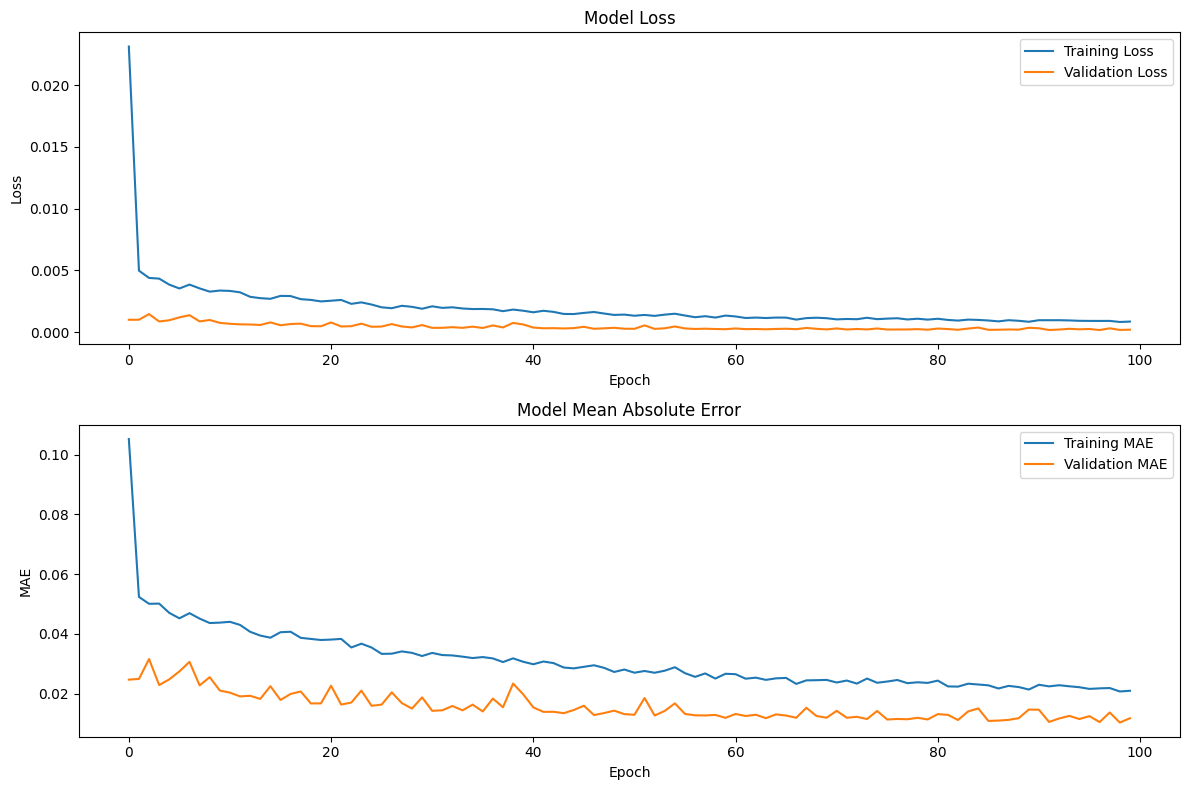

In [49]:
plt.figure(figsize=(12, 8))

# Loss
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE (Mean Absolute Error)
plt.subplot(2, 1, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()


plt.tight_layout()
plt.show()


**SAVE MODEL**

In [51]:
#KONVERSI MODEL KE TFLITE
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Aktifkan variabel resource
converter.experimental_enable_resource_variables = True
# Tetapkan operasi yang didukung dan nonaktifkan penurunan operasi daftar tensor
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()

# Simpan model TFLite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpp7xef_rm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137539082972688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082974608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082975184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082975376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082976336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082976912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082975952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082975760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082973648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082973840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137539082975568: T

In [53]:
import joblib

joblib.dump(scaler, 'scaler.pkl')




['scaler.pkl']